Loan Default Risk with Business Cost Optimization (Home Credit Dataset)

1. Project Setup

In [3]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.linear_model import LogisticRegression

# For advanced model
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings("ignore")

2. Load Dataset

In [5]:
train = pd.read_csv(r"G:\Data Science\DS 27\Data\application_train.csv")

print(train.shape)
train.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


3. Basic Data Understanding

In [6]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


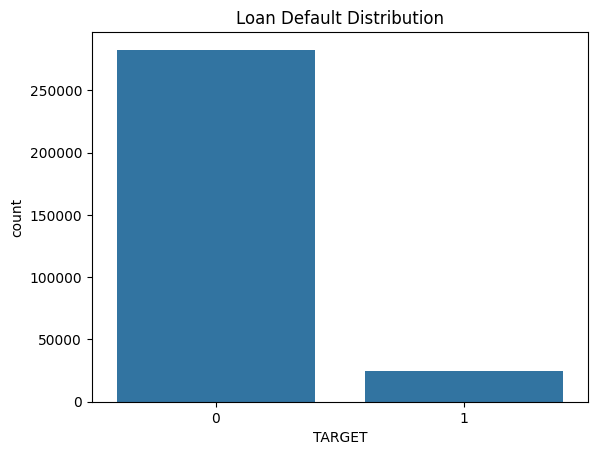

In [7]:
# Target distribution
sns.countplot(x="TARGET", data=train)
plt.title("Loan Default Distribution")
plt.show()

4. Data Cleaning

In [8]:
# Missing values
missing = train.isnull().mean().sort_values(ascending=False)
missing[missing > 0.3]

COMMONAREA_AVG                  0.698723
COMMONAREA_MODE                 0.698723
COMMONAREA_MEDI                 0.698723
NONLIVINGAPARTMENTS_MEDI        0.694330
NONLIVINGAPARTMENTS_MODE        0.694330
NONLIVINGAPARTMENTS_AVG         0.694330
FONDKAPREMONT_MODE              0.683862
LIVINGAPARTMENTS_AVG            0.683550
LIVINGAPARTMENTS_MEDI           0.683550
LIVINGAPARTMENTS_MODE           0.683550
FLOORSMIN_MODE                  0.678486
FLOORSMIN_AVG                   0.678486
FLOORSMIN_MEDI                  0.678486
YEARS_BUILD_AVG                 0.664978
YEARS_BUILD_MODE                0.664978
YEARS_BUILD_MEDI                0.664978
OWN_CAR_AGE                     0.659908
LANDAREA_MEDI                   0.593767
LANDAREA_AVG                    0.593767
LANDAREA_MODE                   0.593767
BASEMENTAREA_MODE               0.585160
BASEMENTAREA_MEDI               0.585160
BASEMENTAREA_AVG                0.585160
EXT_SOURCE_1                    0.563811
NONLIVINGAREA_MO

In [9]:
# Drop columns with too many missing values (>40%)
drop_cols = missing[missing > 0.4].index
train = train.drop(columns=drop_cols)

In [10]:
# Fill numeric missing values with median
num_cols = train.select_dtypes(include=np.number).columns

for col in num_cols:
    train[col].fillna(train[col].median(), inplace=True)

In [11]:
# Fill categorical missing values
cat_cols = train.select_dtypes(include="object").columns

for col in cat_cols:
    train[col].fillna(train[col].mode()[0], inplace=True)

5. Encoding Categorical Variables

In [12]:
train_encoded = pd.get_dummies(train, drop_first=True)
print(train_encoded.shape)

(307511, 173)


6. Train-Test Split

In [13]:
X = train_encoded.drop("TARGET", axis=1)
y = train_encoded["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

7. Feature Scaling

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

8. Logistic Regression Model (Baseline)

In [15]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [16]:
roc_auc_score(y_test, y_prob_log)

0.7446744709161377

9. CatBoost Model (Advanced)

In [17]:
cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    verbose=200
)

cat_model.fit(X_train, y_train)

y_prob_cat = cat_model.predict_proba(X_test)[:, 1]

0:	learn: 0.6405752	total: 331ms	remaining: 2m 45s
200:	learn: 0.2464331	total: 21.8s	remaining: 32.4s
400:	learn: 0.2424049	total: 37.1s	remaining: 9.17s
499:	learn: 0.2407894	total: 44.8s	remaining: 0us


In [18]:
roc_auc_score(y_test, y_prob_cat)

0.7559767643018979

10. ROC Curve Comparison

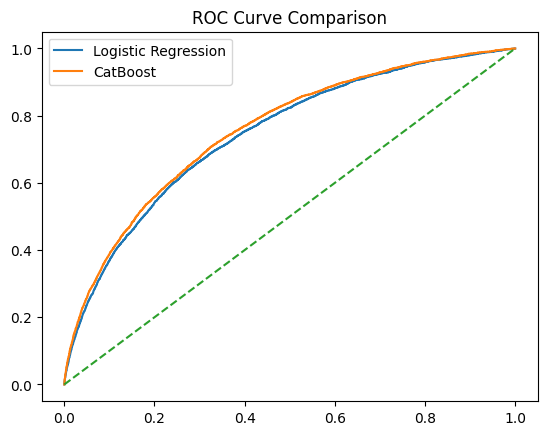

In [19]:
fpr1, tpr1, _ = roc_curve(y_test, y_prob_log)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_cat)

plt.plot(fpr1, tpr1, label="Logistic Regression")
plt.plot(fpr2, tpr2, label="CatBoost")
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

11. Business Cost Function

    Define business logic:
        False Positive (FP): We give loan to risky customer → Loss = 10,000
        False Negative (FN): We reject good customer → Opportunity loss = 2,000

In [20]:
COST_FP = 10000
COST_FN = 2000

12. Threshold Optimization Function

In [21]:
def calculate_cost(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    cost = (fp * COST_FP) + (fn * COST_FN)
    return cost

13. Find Best Threshold

In [22]:
thresholds = np.arange(0.1, 0.9, 0.01)
costs = []

for t in thresholds:
    cost = calculate_cost(y_test, y_prob_cat, t)
    costs.append(cost)

best_threshold = thresholds[np.argmin(costs)]
best_cost = min(costs)

best_threshold, best_cost

(np.float64(0.7199999999999996), np.int64(9930000))

14. Visualize Cost vs Threshold

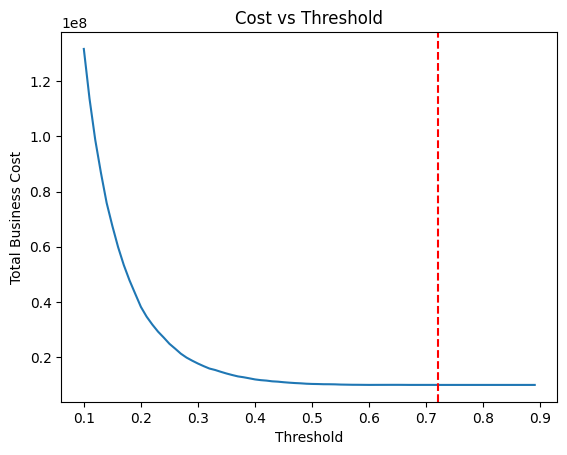

In [23]:
plt.plot(thresholds, costs)
plt.axvline(best_threshold, color='red', linestyle='--')
plt.title("Cost vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Total Business Cost")
plt.show()

15. Final Model at Best Threshold

In [24]:
final_pred = (y_prob_cat >= best_threshold).astype(int)

print(confusion_matrix(y_test, final_pred))
print(classification_report(y_test, final_pred))

[[56538     0]
 [ 4965     0]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503



16. Feature Importance (CatBoost)

In [25]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": cat_model.get_feature_importance()
}).sort_values(by="importance", ascending=False)

feature_importance.head(15)

,feature,importance
28,EXT_SOURCE_3,21.179234
27,EXT_SOURCE_2,18.751685
5,AMT_GOODS_PRICE,5.553257
7,DAYS_BIRTH,5.449861
3,AMT_CREDIT,4.808267
4,AMT_ANNUITY,3.746947
61,CODE_GENDER_M,3.714658
8,DAYS_EMPLOYED,3.651396
78,NAME_EDUCATION_TYPE_Higher education,2.347172
10,DAYS_ID_PUBLISH,2.211340


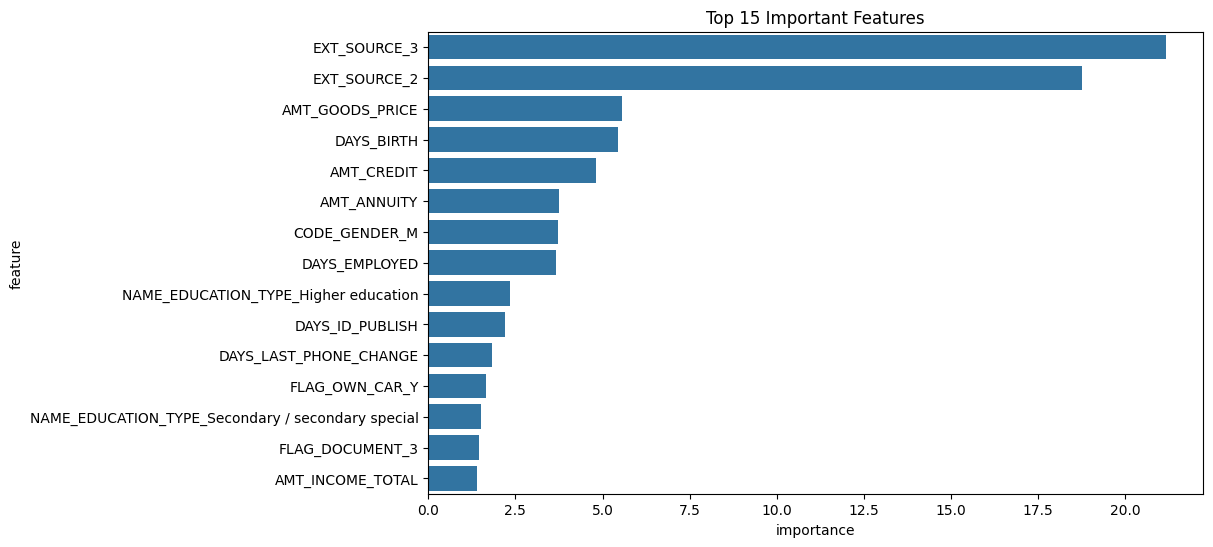

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(15), x="importance", y="feature")
plt.title("Top 15 Important Features")
plt.show()

17. Final Conclusion (for notebook)

### 📌 Conclusion

In this project, we built a machine learning model to predict loan default risk using the Home Credit dataset. We compared Logistic Regression and CatBoost models and found that CatBoost performed better in terms of AUC score.

However, instead of relying only on accuracy metrics, we applied a **business cost-based approach**. By defining financial costs for false positives and false negatives, we optimized the classification threshold to minimize total business loss.

This approach makes the model more practical for real-world financial decision-making, where the cost of wrong predictions is more important than simple accuracy.

Key takeaways:
- Built binary classification models for risk prediction
- Handled missing values and categorical encoding
- Applied CatBoost for high-performance modeling
- Introduced cost-sensitive threshold tuning
- Improved decision-making using business-driven metrics